#Foreign vs Domestic Distribution

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Project_2/TATA-IPL-2025-Auction-Final-List-cleaned.xlsx')

In [3]:
df.head()

,full name,Country,State Association,National/International,Age,Age Group,2024 Team,C/U,Team,Type,Base,Sold,Category
0,Jos Buttler,England,International,International,34,30-35,RR,Capped,GT,BAT,2,15.75,Auctioned
1,Shreyas Iyer,India,MCA,National,30,30-35,KKR,Capped,PBKS,BAT,2,26.75,Auctioned
2,Rishabh Pant,India,DDCA,National,27,25-30,DC,Capped,LSG,BAT,2,27.00,Auctioned
3,Kagiso Rabada,South Africa,International,International,29,25-30,PBKS,Capped,GT,BOWL,2,10.75,Auctioned
4,Arshdeep Singh,India,PCA,National,26,25-30,PBKS,Capped,PBKS,BOWL,2,18.00,Auctioned


##Number of Domestic vs Foreign Players

Business Question

* What is the overall talent pool composition?

In [4]:
player_distribution = (
    df["National/International"]
    .value_counts()
    .rename_axis("Player Type")
    .reset_index(name="Players")
)

player_distribution

,Player Type,Players
0,National,155
1,International,72


**Business Insight:**

The auction pool was primarily composed of **155 domestic players (68.3%)** and **72 overseas players (31.7%)**. This indicates that franchises had a significantly larger domestic talent pool to choose from, making Indian players the foundation of squad building while overseas players were used to fill specialized roles.

##Budget Allocation

Business Question

* How much auction money was invested in domestic vs overseas players?

In [5]:
budget_allocation = (
    df.groupby("National/International")["Sold"]
    .sum()
    .reset_index()
    .sort_values("Sold", ascending=False)
)

budget_allocation

,National/International,Sold
1,National,774.35
0,International,407.75


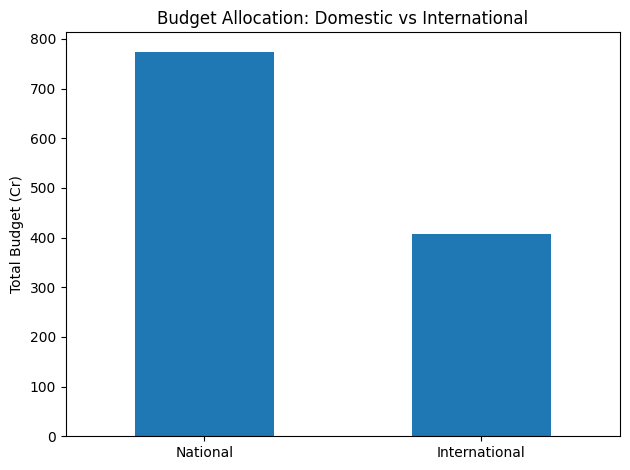

In [12]:
import matplotlib.pyplot as plt

budget_allocation.plot(
    x="National/International",
    y="Sold",
    kind="bar",
    legend=False
)

plt.title("Budget Allocation: Domestic vs International")
plt.xlabel("")
plt.ylabel("Total Budget (Cr)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Business Insight:**

Franchises invested **₹774.35 Cr (65.5%)** in domestic players compared to **₹407.75 Cr (34.5%)** in overseas players. The majority of auction spending was directed toward Indian talent, highlighting that domestic players remain the primary long-term investment for team construction.

##Average Player Price

Business Question

* Are overseas players priced higher than domestic players?

In [6]:
avg_price = (
    df.groupby("National/International")["Sold"]
    .mean()
    .round(2)
    .reset_index()
)

avg_price

,National/International,Sold
0,International,5.66
1,National,5.00


**Business Insight:**

Although teams spent more overall on domestic players, overseas players commanded a slightly higher average price (**₹5.66 Cr**) than domestic players (**₹5.00 Cr**). This suggests franchises are willing to pay a premium for experienced international talent despite purchasing fewer overseas players.


##Team Preference

Business Question

* Which teams prefer overseas talent and which invest more in domestic players?

In [8]:
team_preference = (
    df.pivot_table(
        index="Team",
        columns="National/International",
        values="full name",
        aggfunc="count",
        fill_value=0
    ).reset_index()
)

team_preference

National/International,Team,International,National
0,CSK,7,18
1,DC,7,16
2,GT,7,18
3,KKR,8,13
4,LSG,6,17
5,MI,8,15
6,PBKS,8,17
7,RCB,8,14
8,RR,6,14
9,SRH,7,13


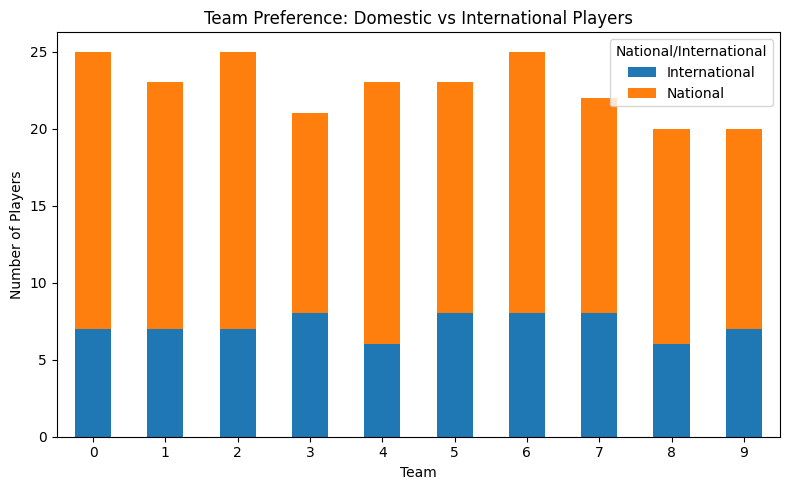

In [13]:
import matplotlib.pyplot as plt

team_preference.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Team Preference: Domestic vs International Players")
plt.xlabel("Team")
plt.ylabel("Number of Players")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Business Insight:**

Most franchises maintained a domestic-heavy squad structure. **CSK and GT** had the highest domestic representation with **18 Indian players**, while **KKR, MI, PBKS, and RCB** selected the highest number of overseas players (**8 each**). This reflects different recruitment strategies, with some teams emphasizing local depth while others balanced their squads with greater international presence.

##Foreign Player Dependency

Business Question

* Which franchises rely most on overseas talent?

In [9]:
foreign_dependency = (
    df.pivot_table(
        index="Team",
        columns="National/International",
        values="Sold",
        aggfunc="sum",
        fill_value=0
    )
)

foreign_dependency["Foreign Dependency %"] = (
    foreign_dependency["International"] /
    foreign_dependency.sum(axis=1)
    * 100
).round(1)

foreign_dependency = foreign_dependency.sort_values(
    "Foreign Dependency %",
    ascending=False
)

foreign_dependency

National/International,International,National,Foreign Dependency %
Team,,,
SRH,60.35,59.45,50.4
GT,52.25,67.60,43.6
KKR,42.40,65.55,39.3
RCB,42.45,76.80,35.6
DC,40.50,76.05,34.7
CSK,39.15,80.80,32.6
RR,36.65,83.05,30.6
LSG,35.40,84.20,29.6
PBKS,31.25,88.40,26.1


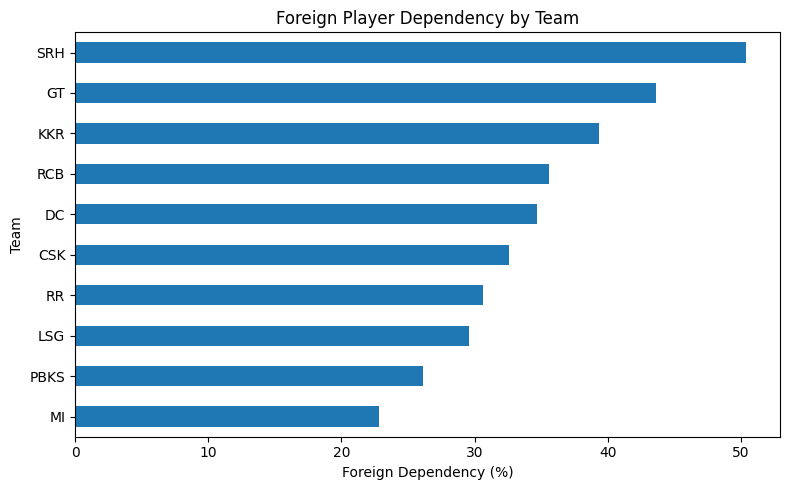

In [15]:
import matplotlib.pyplot as plt

foreign_dependency["Foreign Dependency %"].plot(
    kind="barh",
    figsize=(8,5)
)

plt.gca().invert_yaxis()
plt.title("Foreign Player Dependency by Team")
plt.xlabel("Foreign Dependency (%)")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

**Business Insight:**

**SRH** showed the highest reliance on overseas talent, allocating **50.4%** of its auction budget to international players. In contrast, **MI** had the lowest foreign dependency at **22.8%**, investing nearly four-fifths of its budget in domestic talent. This indicates considerable variation in team-building strategies across franchises.

## Domestic Talent Investment

Business Question

* Which teams invest the most in Indian talent?

In [10]:
domestic_investment = (
    df[df["National/International"]=="National"]
    .groupby("Team")["Sold"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

domestic_investment

,Team,Sold
0,MI,92.45
1,PBKS,88.40
2,LSG,84.20
3,RR,83.05
4,CSK,80.80
5,RCB,76.80
6,DC,76.05
7,GT,67.60
8,KKR,65.55
9,SRH,59.45


**Business Insight:**

**Mumbai Indians (MI)** made the largest investment in domestic players (**₹92.45 Cr**), followed by **PBKS (₹88.40 Cr)** and **LSG (₹84.20 Cr)**. On the other hand, **SRH** invested the least (**₹59.45 Cr**) in Indian players, reflecting a comparatively stronger focus on overseas acquisitions.

# Overall Executive Insight

The IPL auction strategy remained **domestic-centric**, with **68.3% of players** being Indian and **65.5% of the total auction budget (₹774.35 Cr)** invested in domestic talent. However, overseas players continued to command a higher average valuation (**₹5.66 Cr vs ₹5.00 Cr**), indicating their premium market value. Team strategies varied considerably, with **SRH** relying most on international talent (**50.4% foreign budget dependency**) while **MI** focused heavily on domestic investment (**₹92.45 Cr** and only **22.8% foreign dependency**). Overall, franchises used domestic players as the core of their squads while strategically investing in a smaller number of high-value overseas players to strengthen key positions.